## 1.Introduction & Problem Statement📶



---


✍1.สำรวจชุดข้อมูลและแสดงประเด็นที่นำไปสู่การตั้งสมมติฐาน
📜

---



Data name : Student Performance & Behavior Dataset
https://www.kaggle.com/datasets/mahmoudelhemaly/students-grading-dataset/data

---



  #รายละเอียดเบื้องต้นของชุดข้อมูล:

*  จำนวนระเบียน: 5,000 รายการ
*  จำนวนฟีเจอร์: 23 ฟีเจอร์



---



  #ตัวแปรสำคัญ:

*   คะแนนสอบ (Midterm_Score, Final_Score, Total_Score)
*   การเข้าชั้นเรียน (Attendance)
*   พฤติกรรม (Study_Hours_per_Week, Extracurricular_Activities, Sleep_Hours_per_Night)
*   ปัจจัยส่วนบุคคล (Parent_Education_Level, Family_Income_Level, Stress_Level_(1-10), Department)



---


  #ปัญหาที่พบ:

*   มีค่าขาดหาย (Missing Values) ในบางคอลัมน์ เช่น Attendance, Assignments_Avg, และ Parent_Education_Level
* ตัวแปรบางตัวเป็นเชิงหมวดหมู่ที่อาจต้องแปลงเป็นตัวเลขก่อนวิเคราะห์




---
✍2. สมมติฐานเบื้องต้นสำหรับค้นพบความรู้จากชุดข้อมูล
📈

---



*  พฤติกรรมการเรียนและปัจจัยด้านสิ่งแวดล้อมมีผลต่อการที่นักเรียนจะสอบตกหรือไม่?

---




**📊Columns Description📜**


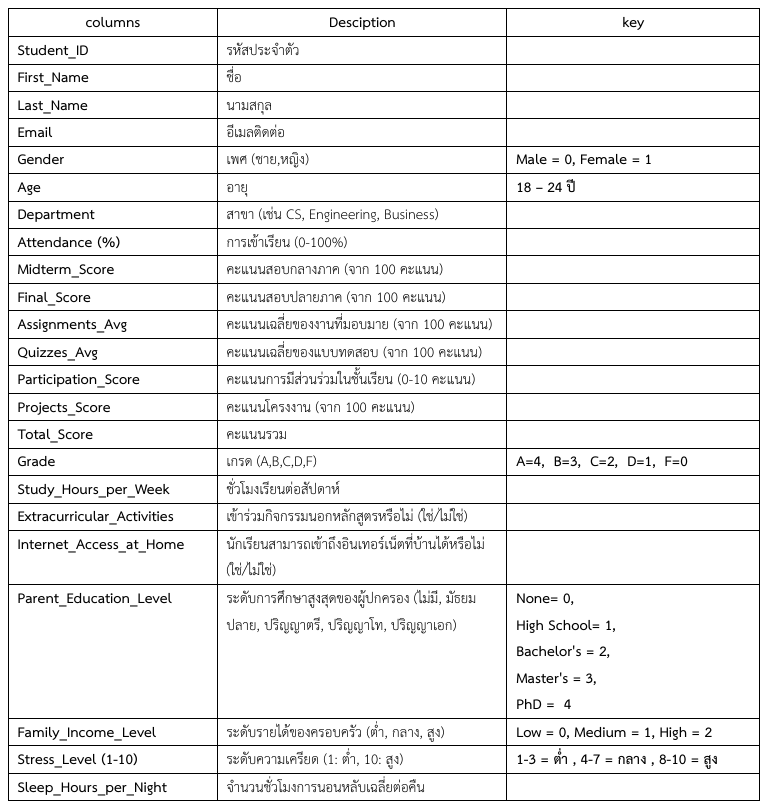



# 2.Data import🌍

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import binarize
from sklearn.linear_model import LogisticRegression

In [ ]:
# โหลดข้อมูลจาก CSV
df = pd.read_csv("Students_Grading_Dataset.csv")
# ดูข้อมูล
df.head()

In [ ]:
# ดูประเภทของข้อมูล
df.info()

## ตรวจสอบขนาดของข้อมูล

In [ ]:
# ตรวจสอบขนาดของข้อมูล
print(f"จำนวนระเบียน: {df.shape[0]}, จำนวนฟีเจอร์: {df.shape[1]}")

In [ ]:
# เช็คค่าสถิติเบื้องต้น
df.describe()

## ตรวจสอบว่ามีคอลัมน์ที่เป็น "คลาส"

In [ ]:
# ตรวจสอบว่ามีคอลัมน์ที่เป็น "คลาส" หรือเป้าหมายสำหรับการจำแนกประเภท
for col in df.columns:
    print(f"{col}: {df[col].nunique()} ")



---
กำลังเริ่มวิเคราะห์ข้อมูลเชิงสำรวจ (EDA)


---



# 3.Exploratory Data Analysis (EDA)

## เช็ค Missing Values

In [ ]:
# ตรวจสอบค่าว่าง
missing_values = df.isnull().sum()
print("จำนวน Missing Values ในแต่ละคอลัมน์ :")
print(missing_values[missing_values > 0])

## Correlation Matrix


การตีความค่าความสัมพันธ์:

*   1 → ความสัมพันธ์เชิงบวกที่สมบูรณ์แบบ
เมื่อตัวแปรหนึ่งเพิ่มขึ้นตัวแปรอื่นก็จะเพิ่มขึ้นด้วย
*   -1 → ความสัมพันธ์เชิงลบที่สมบูรณ์แบบ
เมื่อตัวแปรหนึ่งเพิ่มขึ้น ตัวแปรอื่นก็จะลดลง
*   0 → ไม่มีความสัมพันธ์
การเปลี่ยนแปลงตัวแปรหนึ่งไม่ส่งผลต่อตัวแปรอื่น


In [ ]:
numerical_cols = df.select_dtypes(include=["number"]).columns

# คำนวณค่าสหสัมพันธ์ (Correlation Matrix) ด้วยวิธี Spearman
correlation_matrix = df[numerical_cols].corr(method="spearman")

# แสดงผลลัพธ์เป็นตาราง
display(correlation_matrix)

# สร้าง heatmap แสดงความสัมพันธ์
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Student Performance Features")
plt.show()

## แสดงกราฟข้อมูล และความสัมพันธ์เบื้องต้น

In [ ]:
# กำหนดคอลัมน์ที่เป็นตัวเลขสำหรับพล็อต
numerical_cols = df.select_dtypes(include=["number"]).columns

# ฟังก์ชันพล็อตการกระจายของข้อมูล
def plot_numerical_distribution(df, numerical_cols):
    plt.figure(figsize=(16, 8))
    num_plots = len(numerical_cols)
    rows = (num_plots // 4) + (num_plots % 4 > 0)  # คำนวณจำนวนแถวสำหรับ subplot

    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(rows, 4, i)
        sns.histplot(df[col], kde=True, bins=30, color="#FF0065")
        plt.title(f"Distribution of {col}", fontsize=10)
        plt.xlabel("")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()
plot_numerical_distribution(df, numerical_cols)

### กราฟแสดงเพศ

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(df['Gender'].value_counts(),
        labels=df['Gender'].value_counts().index,
        colors=['#6600FF', '#FF3366'],
        autopct='%1.1f%%',
        wedgeprops=dict(width=0.3, edgecolor='white'))
plt.title("Gender Distribution", fontsize=14)
plt.show()

### กราฟการกระจายของเกรด

In [ ]:
df["Grade_Label"] = df["Grade"]
order = ["A", "B", "C", "D", "F"]

plt.figure(figsize=(10, 5))
k = sns.countplot(data=df, x="Grade_Label", order=order, palette="coolwarm")

# ใส่ตัวเลขบนแท่ง
for p in k.patches:
    height = p.get_height()
    k.annotate(height,
               (p.get_x() + p.get_width() / 2, height + 8),
               ha='center', fontsize=12)

k.set_title("Distribution of Student Grades", fontsize=14)
k.set_xlabel("Grade", fontsize=12)
k.set_ylabel("Count", fontsize=12)
k.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# นับจำนวนเกรด
grade_counts = df["Grade"].value_counts().reindex(["A", "B", "C", "D", "F"])

# กำหนดสีและ explode
colors = ["#6699FF", "#CCFF99", "#FF0066", "#FF66FF", "#FFD700"]
explode = [0.025] * len(grade_counts)

plt.figure(figsize=(8, 8))
plt.pie(grade_counts,
        labels=grade_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        textprops={'fontsize': 14})

plt.title("Grade Distribution (A–F)", fontsize=16, weight='bold', color="#2F0F5D")
plt.legend(title="Grade", loc="upper right")
plt.tight_layout()
plt.show()

### กราฟแสดงการกระจายของเกรดแต่ละสาขา

In [ ]:
df["Grade_Label"] = df["Grade"]
order = ["A", "B", "C", "D", "F"]

plt.figure(figsize=(10, 6))

df_sorted = df["Department"].value_counts().index
My_graph = sns.countplot(
    x="Department",
    hue="Grade_Label",
    data=df,
    order=df_sorted,
    hue_order=["A", "B", "C", "D", "F"],
    palette=colors
)
for p in My_graph.patches:
    height = p.get_height()
    if height > 0:
        My_graph.annotate(f'{int(height)}',
                          (p.get_x() + p.get_width() / 2., height + 5),
                          ha='center', va='bottom', fontsize=10)

My_graph.legend(title="Grade", bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("Department", weight="bold", fontsize=12)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.title("Grade Distribution by Department", weight="bold", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### การกระจายของเกรดแต่ละเพศ

In [ ]:
df["Grade_Label"] = df["Grade"]
order = ["A", "B", "C", "D", "F"]

plt.figure(figsize=(8, 5))
My_graph = sns.countplot(
    x="Gender",
    hue="Grade_Label",
    data=df,
    hue_order=["A", "B", "C", "D", "F"],
    palette=colors
)

for p in My_graph.patches:
    height = p.get_height()
    if height > 0:
        My_graph.annotate(f'{int(height)}',
                          (p.get_x() + p.get_width() / 2., height + 2),
                          ha='center', fontsize=10)

My_graph.legend(title="Grade", bbox_to_anchor=(1, 1), loc="upper left")
plt.title("Grade Distribution by Gender", fontsize=14, weight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# 4.Data Cleaning🎯

### เติมค่า missing value
โดยใช้เทคนิคการเช็คค่ามัธยฐาน 50% (สำหรับข้อมูลที่เป็น number) และค่าฐานนิยม ที่พบบ่อยที่สุด(สำหรับข้อมูลที่เป็นstring)แล้วนำมาเติมโดยใช้คำสั่งfillna

In [ ]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].median())#ค่ามัธยฐาน (Median) ของคอลัมน์ 50%
df["Assignments_Avg"] = df["Assignments_Avg"].fillna(df["Assignments_Avg"].median()) #ค่ามัธยฐาน (Median) ของคอลัมน์ 50%

most_frequent_value = df["Parent_Education_Level"].mode()[0]# หา mode (ค่าที่พบบ่อยที่สุด)
df["Parent_Education_Level"] = df["Parent_Education_Level"].fillna(most_frequent_value)# แทนค่า NaN ด้วยค่า mode
print(df.isnull().sum())  # ดูจำนวนค่าที่หายไปในแต่ละคอลัมน์

### ลบ columns ที่ไม่ได้ใช้

In [ ]:
# ลบคอลัมน์ที่ไม่จำเป็น
columns_to_drop = ["Student_ID", "First_Name" , "Last_Name" , "Email" ]
df.drop(columns=columns_to_drop, inplace=True)
print(df.columns)

หลังจากที่ดูกราฟดูข้อมูลเบื้องต้น พบว่าเกรดของข้อมูลมันดูไม่ยุติธรรมเลยเลือกที่จะสร้างเกรดใหม่  วัดจากคะแนนของเด็กๆที่ๆด้โดยตรงเพื่อความแม่นยำและยุติธรรม

# 5.Feature Engineering

### สร้างเกรดใหม่

In [ ]:
# สร้าง Total_Score_New
df["Total_Score_New"] = (
    df["Midterm_Score"] * 0.20 +
    df["Final_Score"] * 0.30 +
    df["Assignments_Avg"] * 0.15 +
    df["Quizzes_Avg"] * 0.15 +
    df["Projects_Score"] * 0.15 +
    df["Participation_Score"] * 0.05
)

In [ ]:
# สร้าง New_Grade แบบ A-F
def assign_grade(score):
    if score >= 80: return "A"
    elif score >= 70: return "B"
    elif score >= 60: return "C"
    elif score >= 50: return "D"
    else: return "F"

df["New_Grade"] = df["Total_Score_New"].apply(assign_grade)

In [ ]:
# สร้าง New_Failing_Grade
df["New_Failing_Grade"] = df["New_Grade"].apply(lambda x: 1 if x in ["D", "F"] else 0)

In [ ]:
df

## ดูกราฟหลังจากสร้าง Feature ใหม่

### Correlation Matrix

In [ ]:
numerical_cols = df.select_dtypes(include=["number"]).columns

# คำนวณค่าสหสัมพันธ์ (Correlation Matrix) ด้วยวิธี Spearman
correlation_matrix = df[numerical_cols].corr(method="spearman")

# แสดงผลลัพธ์เป็นตาราง
display(correlation_matrix)

# สร้าง heatmap แสดงความสัมพันธ์
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Student Performance Features")
plt.show()

### กราฟการกระจายของเกรด

In [ ]:
df["NewGrade_Label"] = df["New_Grade"]
order = ["A", "B", "C", "D", "F"]

plt.figure(figsize=(10, 5))
k = sns.countplot(data=df, x="NewGrade_Label", order=order, palette="coolwarm")

# ใส่ตัวเลขบนแท่ง
for p in k.patches:
    height = p.get_height()
    k.annotate(height,
               (p.get_x() + p.get_width() / 2, height + 8),
               ha='center', fontsize=12)

k.set_title("Distribution of Student Grades", fontsize=14)
k.set_xlabel("New_Grade", fontsize=12)
k.set_ylabel("Count", fontsize=12)
k.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

### กราฟแสดงการกระจายของเกรดแต่ละสาขา

In [ ]:
df["NewGrade_Label"] = df["New_Grade"]
order = ["A", "B", "C", "D", "F"]

plt.figure(figsize=(10, 6))

df_sorted = df["Department"].value_counts().index
My_graph = sns.countplot(
    x="Department",
    hue="NewGrade_Label",
    data=df,
    order=df_sorted,
    hue_order=["A", "B", "C", "D", "F"],
    palette=colors
)
for p in My_graph.patches:
    height = p.get_height()
    if height > 0:
        My_graph.annotate(f'{int(height)}',
                          (p.get_x() + p.get_width() / 2., height + 5),
                          ha='center', va='bottom', fontsize=10)

My_graph.legend(title="New_Grade", bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("Department", weight="bold", fontsize=12)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.title("New_Grade Distribution by Department", weight="bold", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### การกระจายของเกรดแต่ละเพศ

In [ ]:
df["NewGrade_Label"] = df["New_Grade"]
order = ["A", "B", "C", "D", "F"]

plt.figure(figsize=(8, 5))
My_graph = sns.countplot(
    x="Gender",
    hue="NewGrade_Label",
    data=df,
    hue_order=["A", "B", "C", "D", "F"],
    palette=colors
)

for p in My_graph.patches:
    height = p.get_height()
    if height > 0:
        My_graph.annotate(f'{int(height)}',
                          (p.get_x() + p.get_width() / 2., height + 2),
                          ha='center', fontsize=10)

My_graph.legend(title="Grade", bbox_to_anchor=(1, 1), loc="upper left")
plt.title("New_Grade Distribution by Gender", fontsize=14, weight="bold")
plt.xlabel("New_Grade", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# 6.Data Encoding


## ทำการแปลงข้อมูลให้เป็นตัวเลข

In [ ]:
# แปลงข้อมูลแบบ Mapping
gender_mapping = {"Male": 0, "Female": 1}
grade_mapping = {"A": 4, "B": 3, "C": 2, "D": 1, "F": 0}
activity_mapping = {"No": 0, "Yes": 1}
internet_mapping = {"No": 0, "Yes": 1}
education_mapping = {"None": 0, "High School": 1, "Bachelor's": 2, "Master's": 3, "PhD": 4}
income_mapping = {"Low": 0, "Medium": 1, "High": 2}

df["Gender"] = df["Gender"].map(gender_mapping).fillna(-1).astype(int)
df["Extracurricular_Activities"] = df["Extracurricular_Activities"].map(activity_mapping).fillna(-1).astype(int)
df["Internet_Access_at_Home"] = df["Internet_Access_at_Home"].map(internet_mapping).fillna(-1).astype(int)
df["Parent_Education_Level"] = df["Parent_Education_Level"].map(education_mapping).fillna(-1).astype(int)
df["Family_Income_Level"] = df["Family_Income_Level"].map(income_mapping).fillna(-1).astype(int)

# ตรวจสอบ NaN
print(df.isna().sum())

# 7.Model Selection, Training and Evaluation

## แบ่งเกรด

In [ ]:
# แบ่งเกรด (1 = Fail => F, D || 0 = Pass => A, B, C)
df["New_Failing_Grade"] = df["New_Grade"].apply(lambda x: 1 if x in ["D", "F"] else 0)

# แสดงจำนวน Pass/Fail
print(df["New_Failing_Grade"].value_counts())


## เด็กสาขาไหนมีอัตราการสอบตกสูงที่สุด?

In [ ]:
# คำนวณอัตราการสอบตกของแต่ละสาขา
fail_rates = df.groupby("Department")["New_Failing_Grade"].mean().sort_values(ascending=False)

# แสดงผลลัพธ์
print(" อัตราการสอบตกตามแผนก:")
print(fail_rates)

# หาสาขาที่มีอัตราการสอบตกสูงที่สุด
top_department = fail_rates.idxmax()
top_rate = fail_rates.max()

print(f"\nสาขาที่มีอัตราการสอบตกมากที่สุด คือ {top_department} ({top_rate:.2%})")

## ปัจจัยใดส่งผลทำให้เด็กสอบตก?

เปรียบเทียบเพื่อเลือกโมเดลที่แม่นยำที่สุด


 ### Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# สร้างฟีเจอร์และ Target
features = ["Attendance", "Study_Hours_per_Week", "Stress_Level_(1-10)",
            "Sleep_Hours_per_Night", "Parent_Education_Level", "Family_Income_Level"]
X = df[features]
y = df["New_Failing_Grade"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# แบ่ง Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# สร้างและเทรน Logistic Regression
log_model = LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)
log_model.fit(X_train, y_train)

# ทำนายผล
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# ประเมินผล
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# สร้างตารางวิเคราะห์ Coefficients
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
})
coef_df["Impact"] = coef_df["Coefficient"].apply(lambda x: "เพิ่มโอกาสสอบตก" if x > 0 else "ลดโอกาสสอบตก")
coef_df = coef_df.sort_values(by="Coefficient", ascending=False).reset_index(drop=True)

print("\n✅ Accuracy:",accuracy)
print(f"\n🔵ROC AUC Score: {roc_auc:.3f}")
print("\n📋 Classification Report:\n",report)
print("\n🧊 Confusion Matrix:\n" ,conf_matrix)
print("\n📊 Coefficient Table:\n")
print(coef_df.to_string(index=False))


# วาดกราฟ Coefficient ของ Logistic Regression
plt.figure(figsize=(8, 5))
sns.barplot(x="Coefficient", y="Feature", data=coef_df, palette="coolwarm")
plt.title("Logistic Regression")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

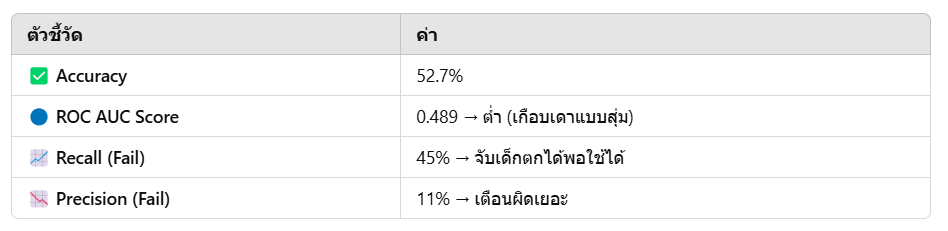

✅ Coefficients ของ Stress และ Study Hours สอดคล้องกับความคาดหวัง
❌ แต่ Attendance และ Sleep Hours กลับดู “เพิ่มโอกาสตก” ซึ่งดูแปลก

→ อาจเกิดจาก multicollinearity หรือ การตีความแบบเส้นตรงของโมเดล

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))
])

# K-Fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross Validation
log_scores = cross_val_score(pipeline, X, y, cv=kf, scoring="accuracy")

print(f"Mean Accuracy (with scaling): {np.mean(log_scores):.4f}")
print("Scores for each fold:", log_scores)

📍 ข้อสรุป:
ค่า Accuracy  50.40%  ค่อนข้าง คงที่ ในแต่ละ fold แต่ยัง ไม่สูงมาก
แสดงให้เห็นว่า Logistic Regression อาจไม่เหมาะที่สุด กับข้อมูลชุดนี้

ใช้ Logistic Regression เพื่อ ตีความความสัมพันธ์ของฟีเจอร์ ได้ดี (เช่นดูทิศทางบวก/ลบของแต่ละปัจจัย) แต่ไม่เหมาะใช้ทำนายผลลัพธ์

📌 สรุปคำตอบคุณ:
โมเดลนี้ เหมาะสำหรับวิเคราะห์ปัจจัย แต่ ไม่เหมาะใช้ทำนายจริงจัง



### RandomForest

In [ ]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, KFold
import numpy as np

# ใช้ฟีเจอร์ที่มีอยู่แล้ว
features = ["Attendance", "Study_Hours_per_Week", "Stress_Level_(1-10)",
            "Sleep_Hours_per_Night", "Parent_Education_Level", "Family_Income_Level"]
X = df[features]
y = df["New_Failing_Grade"]

# แบ่ง Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ปรับโมเดล: เพิ่มจำนวนต้นไม้, จำกัดความลึก, บาลานซ์คลาส
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ประเมินผล
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
conf_rf = confusion_matrix(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\n✅ Accuracy:",accuracy_rf)
print(f"\n🔵ROC AUC Score: {roc_auc_rf:.3f}")
print("\n📋 Classification Report:\n",report_rf)
print("\n🧊 Confusion Matrix:\n" ,conf_rf)

# แสดงผลลัพธ์ Feature Importance เป็นกราฟแท่ง
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature", hue="Feature", dodge=False, palette="coolwarm", legend=False)
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance in Predicting Failing Grade")
plt.show()

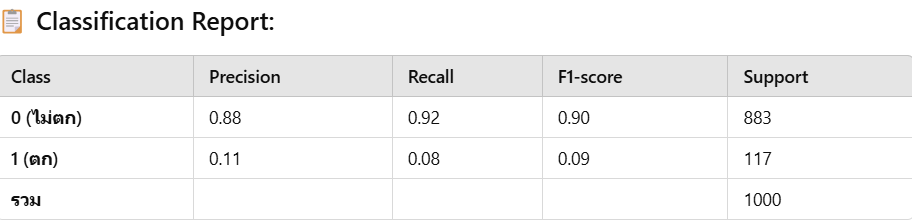

🔍 แม่นยำกับกลุ่มนักเรียนที่ไม่ตกได้ดีมาก
⚠️ แต่ยังตรวจจับนักเรียนที่ตกได้น้อย

→ Recall ต่ำสำหรับ class 1 (ตก)

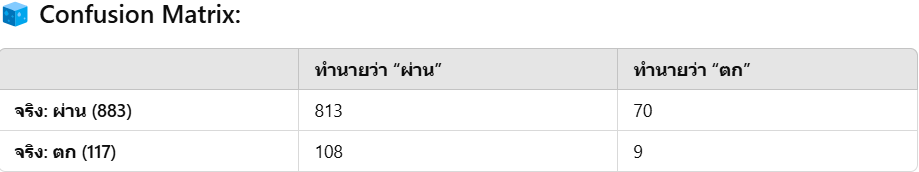
🔵 False Negative ค่อนข้างเยอะ (เด็กที่ตกแต่โมเดลบอกว่าไม่ตก)

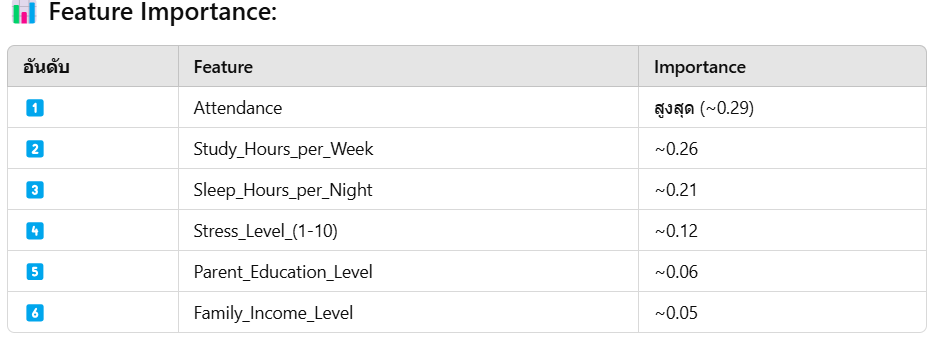
🎯 พฤติกรรมการเข้าเรียน และเวลาศึกษา คือปัจจัยสำคัญอันดับต้น ๆ
💡 โมเดลเข้าใจได้ง่าย และให้ข้อมูลปัจจัยได้ชัดเจน

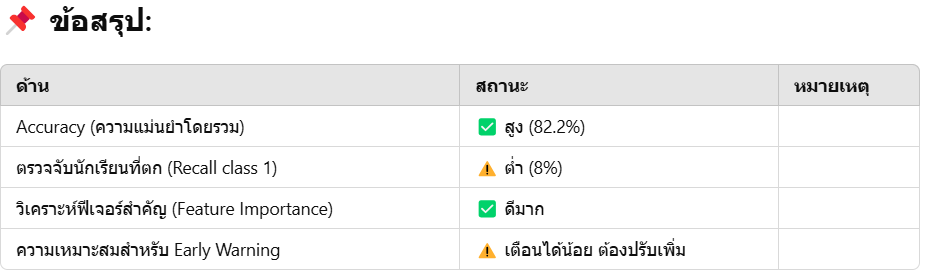

In [ ]:
# Cross Validation สำหรับ Random Forest
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=kf, scoring="accuracy")

# แสดงผลลัพธ์
print(f"Mean Accuracy (10-Fold CV): {np.mean(rf_scores):.4f}")
print("Random Forest Accuracy for each fold:", rf_scores)

📌 สรุป:
🎯 Mean Accuracy (เฉลี่ย): 80.00% ถือว่าอยู่ในระดับที่ดีมาก

📉 ไม่มี Fold ไหนต่ำกว่า 0.77 → โมเดลมีความ เสถียร (Stable)

✅ ช่วยยืนยันว่าโมเดล Random Forest ของคุณ ไม่ Overfitting กับชุดข้อมูล Training


### XGBoost


In [ ]:
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# สร้างและฝึก XGBoost โมเดล
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ประเมินผลโมเดล
acc_xgb = accuracy_score(y_test, y_pred_xgb)
rep_xgb = classification_report(y_test, y_pred_xgb)
conf_xgb = confusion_matrix(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("✅ Accuracy:", acc_xgb)
print(f"\n🔵ROC AUC Score: {roc_auc_xgb:.3f}")
print("\n📋 Classification Report:\n", rep_xgb)
print("\n🧊 Confusion Matrix:\n", conf_xgb)

# ใช้ SHAP อธิบายผลลัพธ์ของ XGBoost
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# แสดงกราฟ SHAP Summary Plot
plt.title("🔍 SHAP Summary Plot for XGBoost")
shap.summary_plot(shap_values, X_test, show=True)

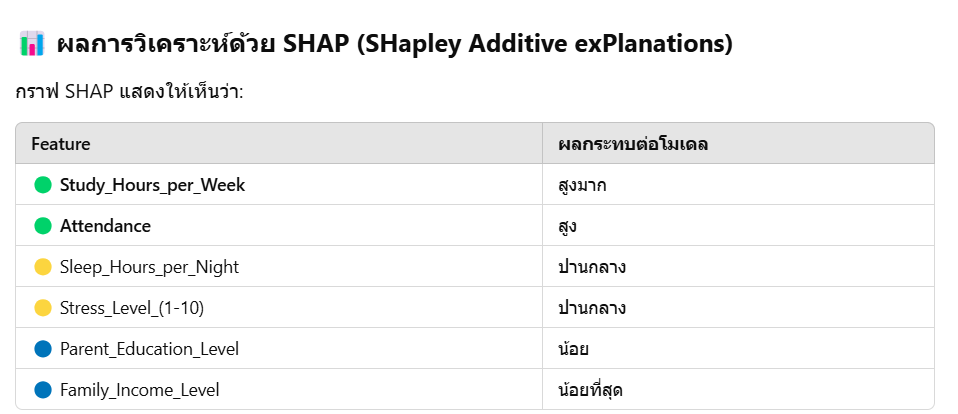

🔍 สรุป Insight

นักเรียนที่ เรียนเยอะ + เข้าเรียนสม่ำเสมอ → มีโอกาส สอบผ่านสูง

นักเรียนที่ นอนน้อยหรือเครียดมาก → เพิ่มโอกาส สอบตก

ปัจจัยอย่าง รายได้ครอบครัว และการศึกษาผู้ปกครอง ส่งผลน้อย

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
# Cross Validation สำหรับ XGBoost
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                          scale_pos_weight=5, subsample=0.8, colsample_bytree=0.8,
                          tree_method="hist", random_state=42)
xgb_scores = cross_val_score(xgb_model, X, y, cv=kf, scoring="accuracy")
# แสดงผลลัพธ์
print("Mean XGBoost Accuracy:", np.mean(xgb_scores))
print("Mean XGBoost Accuracy for each fold:", xgb_scores)

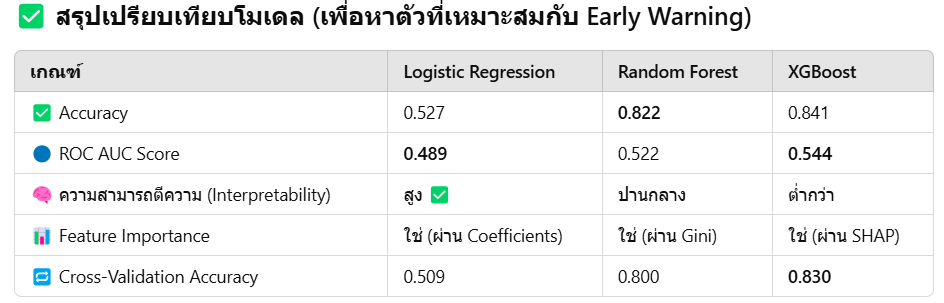

🎯 สรุปคำแนะนำ
✅ ควรใช้ XGBoost ในการพัฒนา Early Warning System
เพราะแม่นยำสุด และสามารถอธิบายผลลัพธ์ได้ด้วย SHAP

## แก้ไขยังไงดี?

หลังเลือกโมเดลที่ดีที่สุด (XGBoost) จึงนำมาสร้าง Early Warning Model เตือนเด็กที่เสี่ยงสอบตก

### 🧠 Early Warning Model


---


Early Warning Model คือระบบที่ใช้เทคนิค Machine Learning ในการประมวลผลข้อมูลพฤติกรรมและสภาพแวดล้อมของนักเรียน เพื่อ ทำนายความเสี่ยง ที่นักเรียนแต่ละคนอาจจะ สอบตก หรือ มีผลการเรียนไม่ดีในอนาคต



---





---


🧩 ข้อมูลที่ใช้ในการทำนาย เช่น:


✅ Attendance – อัตราการเข้าเรียน

📚 Study Hours per Week – จำนวนชั่วโมงที่ใช้ในการเรียนรู้

😰 Stress Level – ระดับความเครียด

😴 Sleep Hours – ชั่วโมงการนอนเฉลี่ยต่อคืน

🎓 Parent Education Level – ระดับการศึกษาของผู้ปกครอง

💰 Family Income Level – รายได้ครอบครัว


---





---


🎯 จุดประสงค์ของโมเดล
🔎 ค้นหานักเรียนที่ มีความเสี่ยงสูงต่อการสอบตก

⚠️ แจ้งเตือนครู / เจ้าหน้าที่ล่วงหน้า

📈 ช่วยให้โรงเรียนสามารถ วางแผนการช่วยเหลือ ได้ตรงจุด เช่น ติวเสริม / ที่ปรึกษา


---



In [ ]:
# ใช้ข้อมูลทั้งหมดในการเทรน เพื่อหาผลลัพธ์
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# เตรียมฟีเจอร์
df["Department"] = LabelEncoder().fit_transform(df["Department"].astype(str))
features = ["Attendance", "Study_Hours_per_Week", "Stress_Level_(1-10)",
            "Sleep_Hours_per_Night", "Department"]
X = df[features]
y = df["New_Failing_Grade"]

# SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# เทรนโมเดล XGBoost
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)
model.fit(X_resampled, y_resampled)

# ทำนายความน่าจะเป็นสอบตก
y_prob = model.predict_proba(X)[:, 1]
y_pred = binarize(y_prob.reshape(-1, 1), threshold=0.45).ravel()

# ประเมินผล
print("✅ Accuracy:", accuracy_score(y, y_pred))
print("🔵 ROC AUC Score:", roc_auc_score(y, y_prob))
print("\n📋 Classification Report:\n", classification_report(y, y_pred))
print("🧊 Confusion Matrix:\n", confusion_matrix(y, y_pred))


In [ ]:
df["Fail_Probability"] = y_prob
df["Predicted_Fail"] = y_pred
at_risk = df[df["Predicted_Fail"] == 1].sort_values(by="Fail_Probability", ascending=False)

# ดูนักเรียนที่ควรแจ้งเตือน
at_risk[["Attendance", "Study_Hours_per_Week", "Fail_Probability", "New_Grade"]].head(10)

# สรุป
print("🧮 นักเรียนทั้งหมด:", len(df))
print("👎 เด็กตกจริง:", df["New_Failing_Grade"].sum())
print("📢 เด็กที่โมเดลเตือน:", at_risk.shape[0])
print("✅ แจ้งเตือนถูก (ตกจริง):", ((df["Predicted_Fail"] == 1) & (df["New_Failing_Grade"] == 1)).sum())


In [ ]:
# ดูรายชื่อเด็กที่ตก (หรือที่ระบบทำนายว่าเสี่ยงตก)
at_risk = df[df["Predicted_Fail"] == 1][
    ["Attendance", "Study_Hours_per_Week", "Stress_Level_(1-10)",
     "Sleep_Hours_per_Night", "Department", "New_Grade", "Fail_Probability"]
]

# แสดงแค่ 10 คนแรก
at_risk.head(10)